[✅] Found dataset file: creditcard.csv
[📋] Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962


📉 Confusion Matrix:


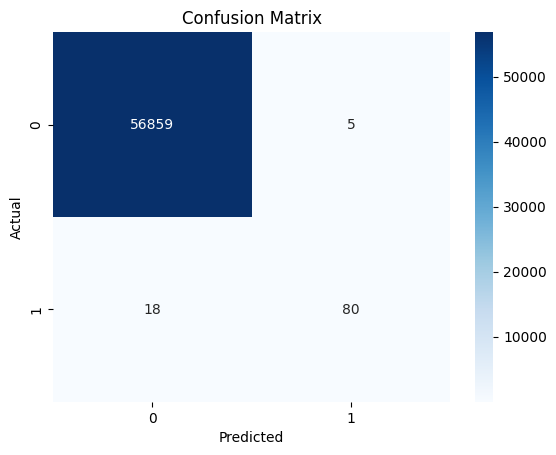


✅ Accuracy: 0.9996
💾 Model saved as fraud_detection_model.pkl


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ✅ Dataset path (change this if CSV is elsewhere)
file_path = Path("creditcard.csv")

if not file_path.exists():
    print(f"[❌ ERROR] Dataset file not found at: {file_path.resolve()}")
    print("👉 Please download it from Kaggle and place it in this same folder.")
    exit()
else:
    print(f"[✅] Found dataset file: {file_path}")
    df = pd.read_csv(file_path)

# ✅ Confirm columns
print("[📋] Columns:", df.columns.tolist())

# ✅ Required columns check
for col in ['Time', 'Amount', 'Class']:
    if col not in df.columns:
        print(f"[❌] Column '{col}' is missing.")
        exit()

# ✅ Scale Time & Amount
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time_scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df = df.drop(['Time', 'Amount'], axis=1)

# ✅ Split features/labels
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# ✅ Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ✅ Evaluate
y_pred = model.predict(X_test)
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n📉 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {accuracy:.4f}")

# ✅ Save model
joblib.dump(model, "fraud_detection_model.pkl")
print("💾 Model saved as fraud_detection_model.pkl")
